In [13]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
def get_weighted_stats(group_df, val_col="latency", weight_col="count", label="") -> dict:
    """
    Calculates weighted boxplot statistics (min, q1, median, q3, max)
    Assumes group_df is already sorted by val_col if not done previously.

    @returns Dictionary of percentiles
    """
    d = group_df.sort_values(val_col)
    data = d[val_col]
    weights = d[weight_col]

    cumsum = weights.cumsum()
    cutoff = cumsum / cumsum.iloc[-1]

    # function to find value at specific percentile
    def get_quantile(q):
        # searchsorted finds the index where the cumulative weight passes the quantile
        idx = np.searchsorted(cutoff, q)
        return data.iloc[idx]

    ret = {
        "med": get_quantile(0.5),
        "q1": get_quantile(0.25),
        "q3": get_quantile(0.75),
        "whislo": data.min(),  # 0th percentile
        "whishi": get_quantile(0.99)   # 100th percentile
        # "whishi": data.max()   # 100th percentile
    }

    if label != "":
        ret["label"] = label

    return ret


In [15]:
services = ["redis", "valkey", "keydb", "acdis"]
#services = ["redis", "valkey", "keydb"]
cluster_sizes = [1,3,4,5]
cluster_percentiles = { size: {} for size in cluster_sizes}
# Save the median latencies of SET,GET,DEL for sizes 1,3,4,5
cmd_latencies = { service: [] for service in services}

# Create output directories
for i in cluster_sizes:
    d = f"images/{i}-nodes/"
    if not os.path.isdir(d):
        os.makedirs(d)

In [16]:
all_folders = {
    1: ["single-node/redis", "single-node/valkey", "single-node/keydb", "single-node/acdis"],
    3: ["three-nodes/redis", "three-nodes/valkey", "three-nodes/keydb", "three-nodes/acdis"],
    4: ["four-nodes/redis", "four-nodes/valkey", "four-nodes/keydb", "four-nodes/acdis"],
    5: ["five-nodes/redis", "five-nodes/valkey", "five-nodes/keydb", "five-nodes/acdis"]
}

#all_folders = {
#    1: ["single-node/redis", "single-node/valkey", "single-node/keydb"],
#    3: ["three-nodes/redis", "three-nodes/valkey", "three-nodes/keydb"],
#    4: ["four-nodes/redis", "four-nodes/valkey", "four-nodes/keydb"],
#    5: ["five-nodes/redis", "five-nodes/valkey", "five-nodes/keydb"]
#}

,latency,count
174,257,698987
175,259,708595
176,261,730730
177,263,752461
178,265,771043
...,...,...
297,503,2995
298,505,2917
299,507,2792
300,509,2814


,latency,count
174,257,349493
175,259,354297
176,261,365365
177,263,376230
178,265,385521
...,...,...
297,503,1497
298,505,1458
299,507,1396
300,509,1407


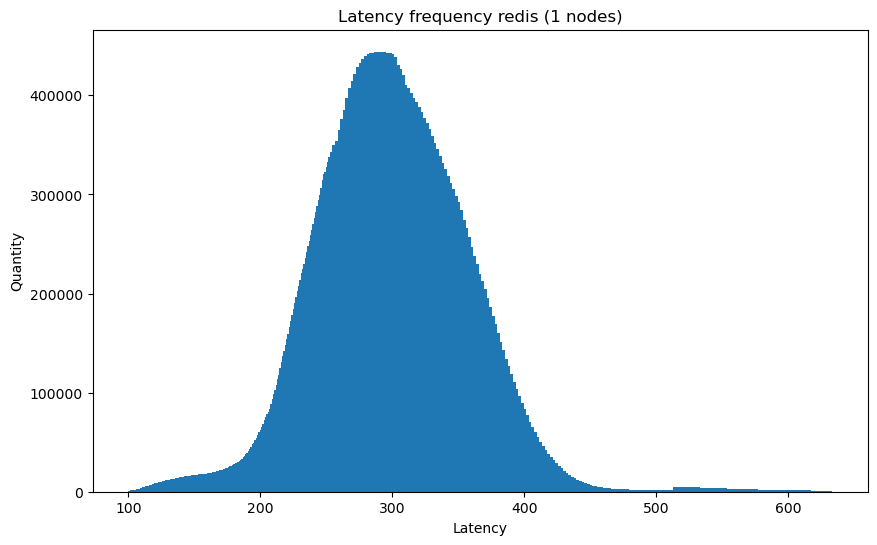

redis DEL: 299  μs
redis GET: 297  μs
redis SET: 301  μs


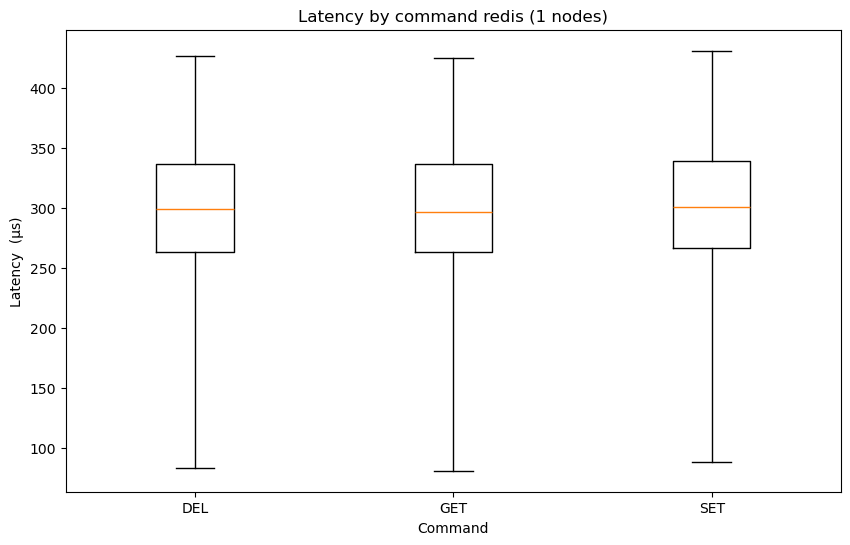

,latency,count
181,257,88630
182,259,92111
183,261,94419
184,263,95198
185,265,95050
...,...,...
304,503,5284
305,505,5015
306,507,5020
307,509,4813


,latency,count
181,257,44315
182,259,46055
183,261,47209
184,263,47599
185,265,47525
...,...,...
304,503,2642
305,505,2507
306,507,2510
307,509,2406


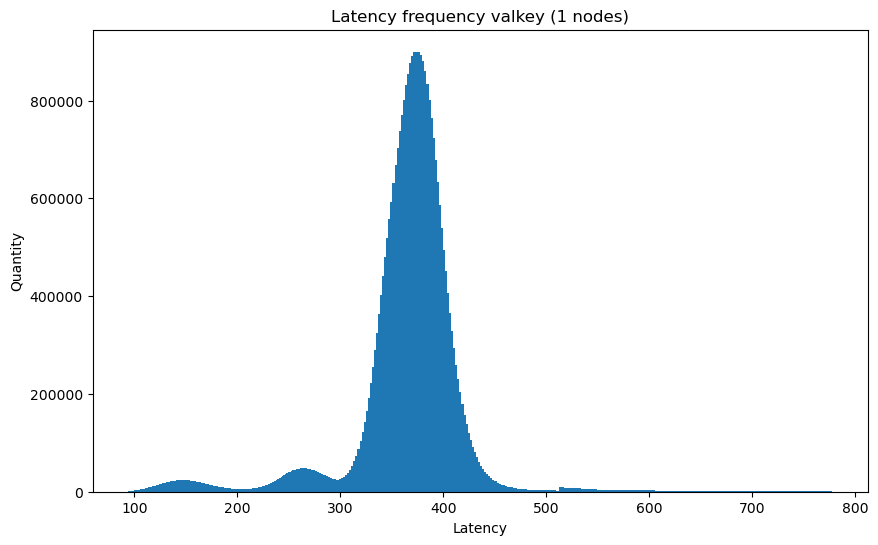

valkey DEL: 371  μs
valkey GET: 371  μs
valkey SET: 373  μs


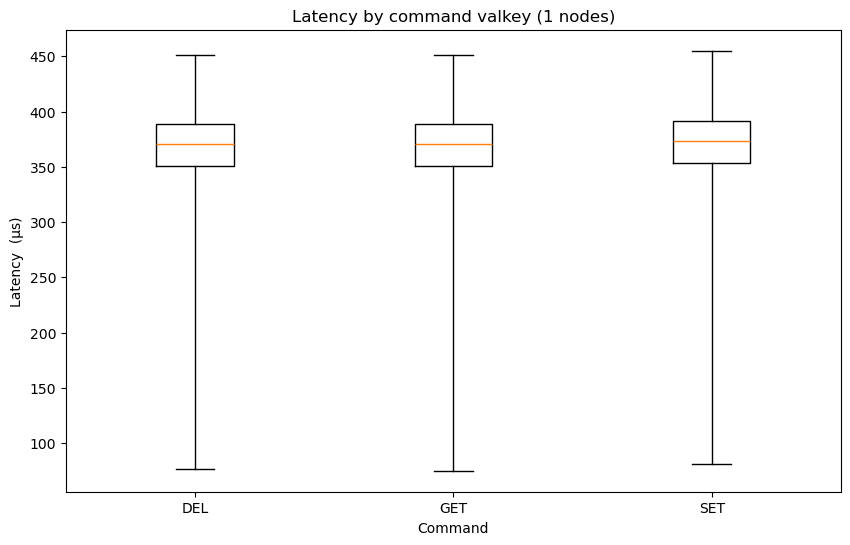

,latency,count
182,257,89809
183,259,87566
184,261,85204
185,263,84705
186,265,83156
...,...,...
305,503,3433
306,505,3491
307,507,3303
308,509,3294


,latency,count
182,257,44904
183,259,43783
184,261,42602
185,263,42352
186,265,41578
...,...,...
305,503,1716
306,505,1745
307,507,1651
308,509,1647


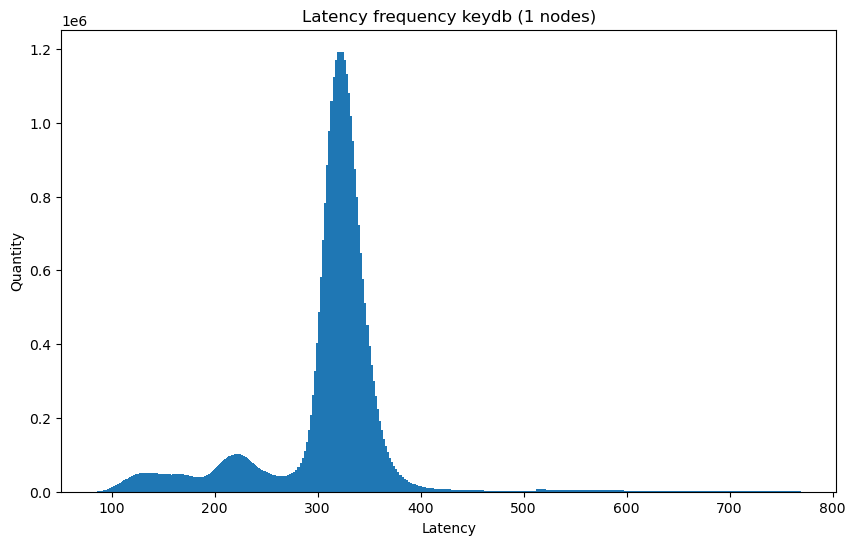

keydb DEL: 321  μs
keydb GET: 321  μs
keydb SET: 323  μs


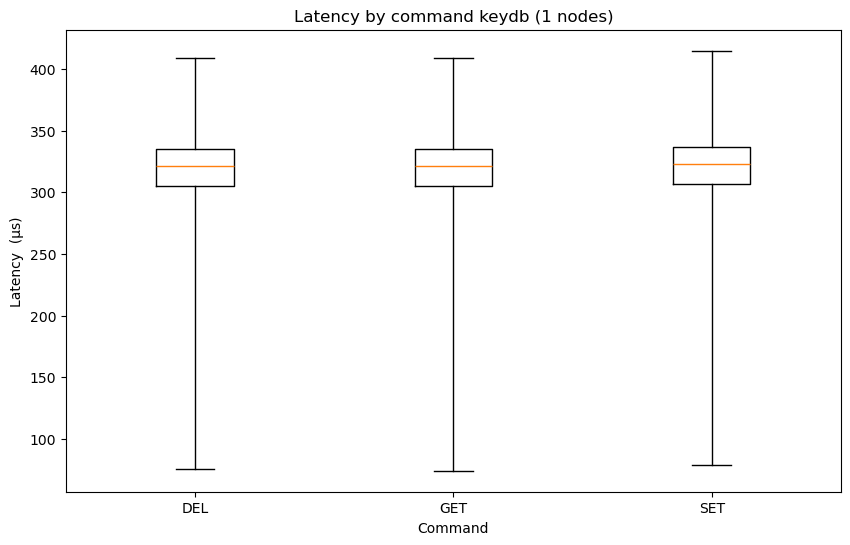

,latency,count
167,257,1240
168,259,1144
169,261,1283
170,263,1322
171,265,1336
...,...,...
290,503,1011
291,505,1034
292,507,1075
293,509,1026


,latency,count
167,257,620
168,259,572
169,261,641
170,263,661
171,265,668
...,...,...
290,503,505
291,505,517
292,507,537
293,509,513


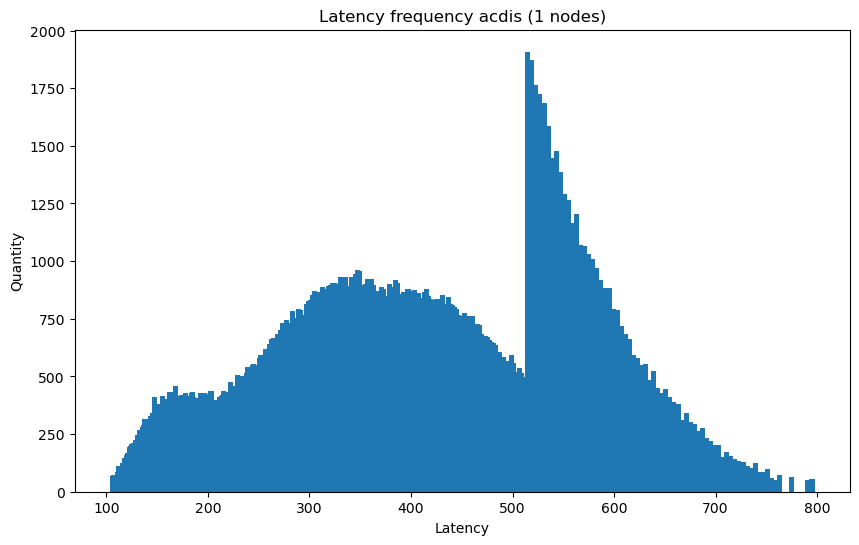

acdis DEL: 371  μs
acdis GET: 369  μs
acdis SET: 375  μs


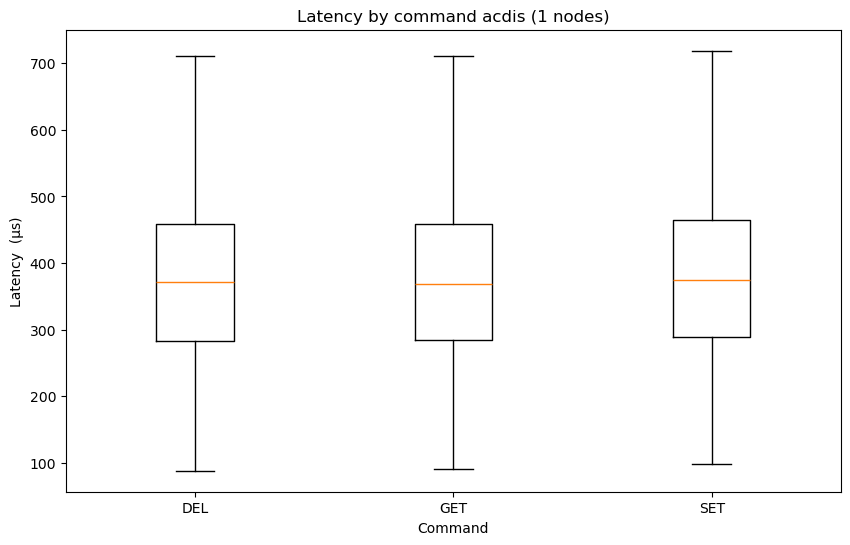

,latency,count
181,257,59472
182,259,55473
183,261,51307
184,263,48537
185,265,44666
...,...,...
251,397,1143
252,399,1181
253,401,1138
254,403,1126


,latency,count
181,257,29736
182,259,27736
183,261,25653
184,263,24268
185,265,22333
...,...,...
251,397,571
252,399,590
253,401,569
254,403,563


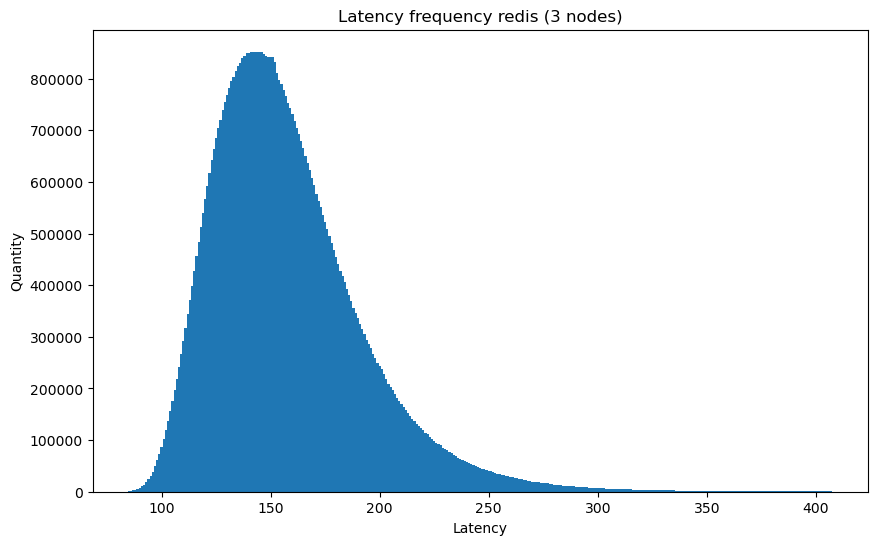

redis DEL: 153  μs
redis GET: 152  μs
redis SET: 158  μs


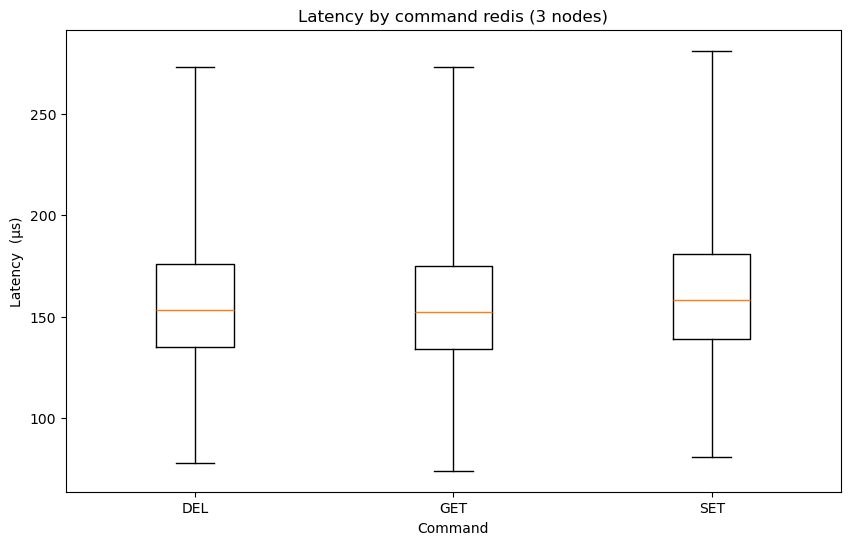

,latency,count
186,257,112775
187,259,108229
188,261,104594
189,263,100160
190,265,96416
...,...,...
272,429,1176
273,431,1164
274,433,1128
276,437,1022


,latency,count
186,257,56387
187,259,54114
188,261,52297
189,263,50080
190,265,48208
...,...,...
272,429,588
273,431,582
274,433,564
276,437,511


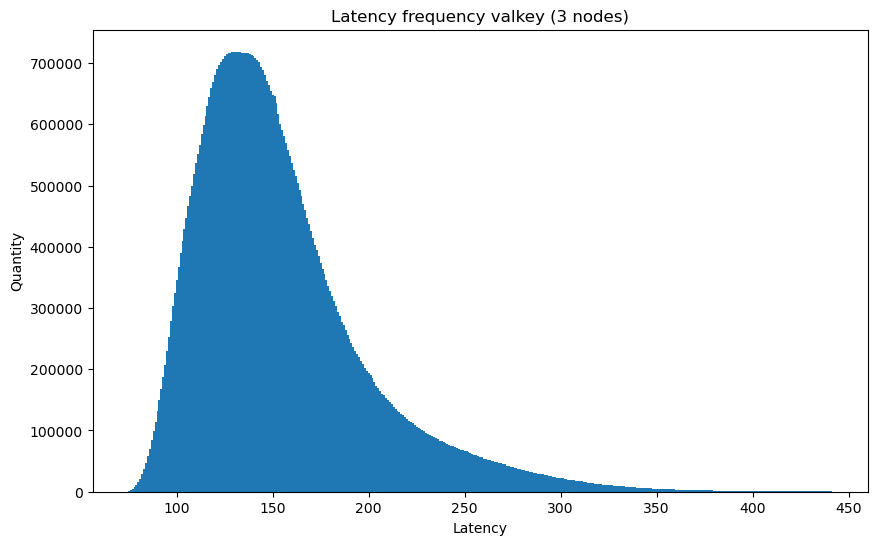

valkey DEL: 146  μs
valkey GET: 145  μs
valkey SET: 150  μs


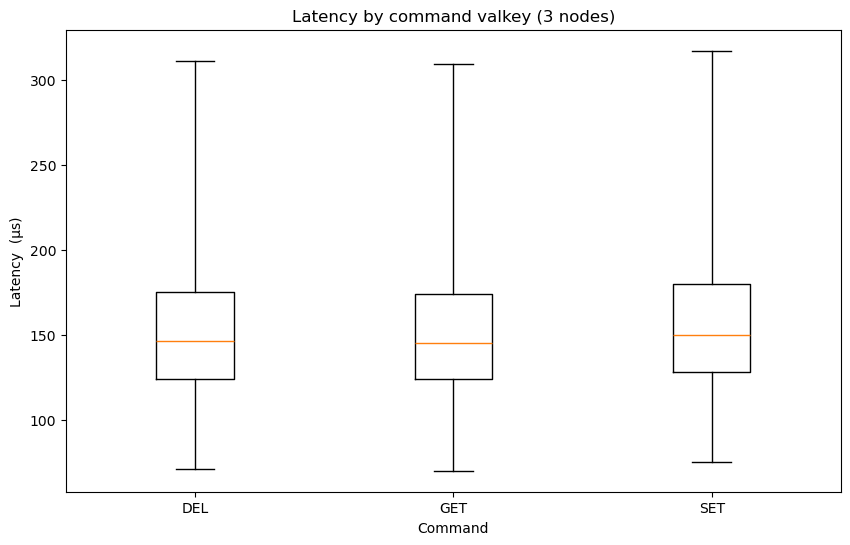

,latency,count
183,257,14655
184,259,13520
185,261,12580
186,263,11736
187,265,10940
...,...,...
250,391,1142
251,393,1135
252,395,1030
253,397,1039


,latency,count
183,257,7327
184,259,6760
185,261,6290
186,263,5868
187,265,5470
...,...,...
250,391,571
251,393,567
252,395,515
253,397,519


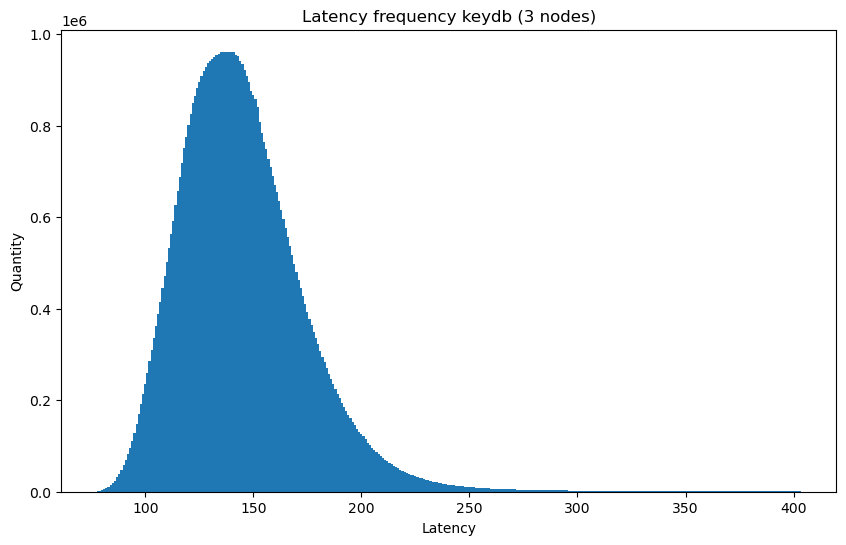

keydb DEL: 142  μs
keydb GET: 141  μs
keydb SET: 148  μs


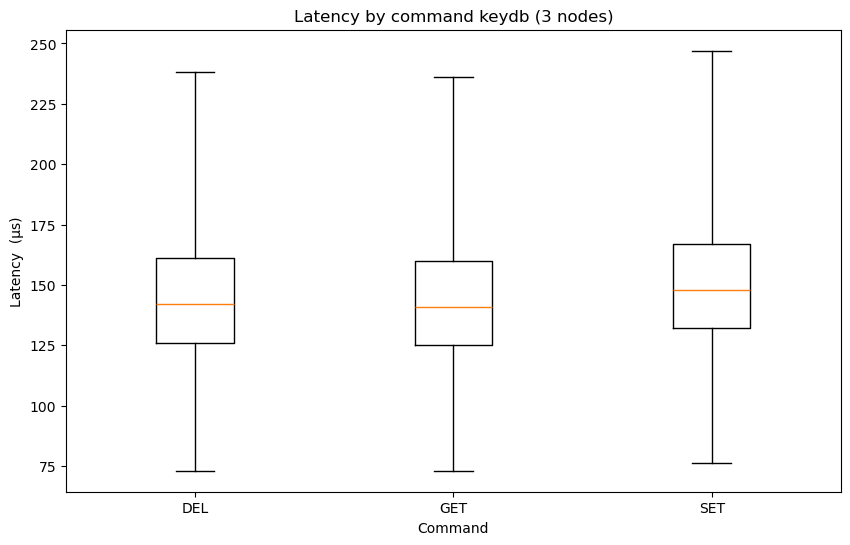

,latency,count
167,257,392
168,259,340
169,261,303
170,263,310
171,265,301
...,...,...
290,503,77
291,505,83
292,507,69
293,509,89


,latency,count
167,257,196
168,259,170
169,261,151
170,263,155
171,265,150
...,...,...
290,503,38
291,505,41
292,507,34
293,509,44


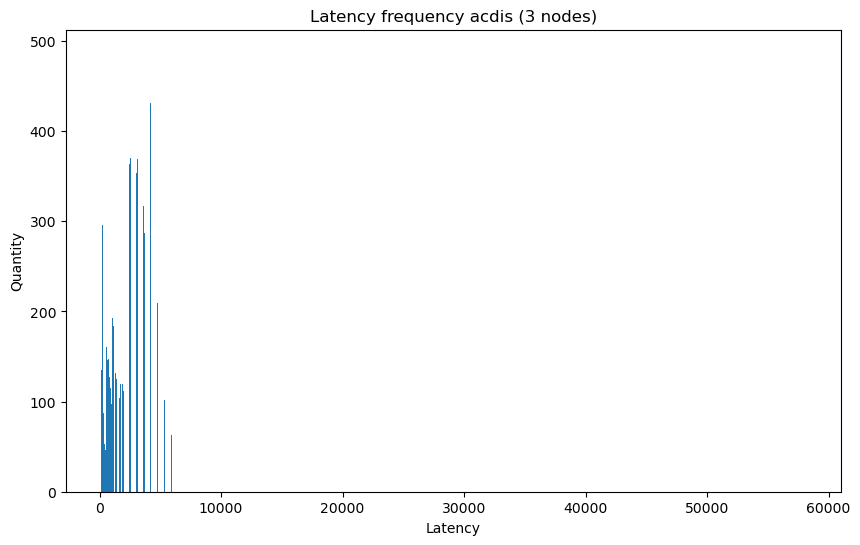

acdis DEL: 1831  μs
acdis GET: 1247  μs
acdis SET: 1295  μs


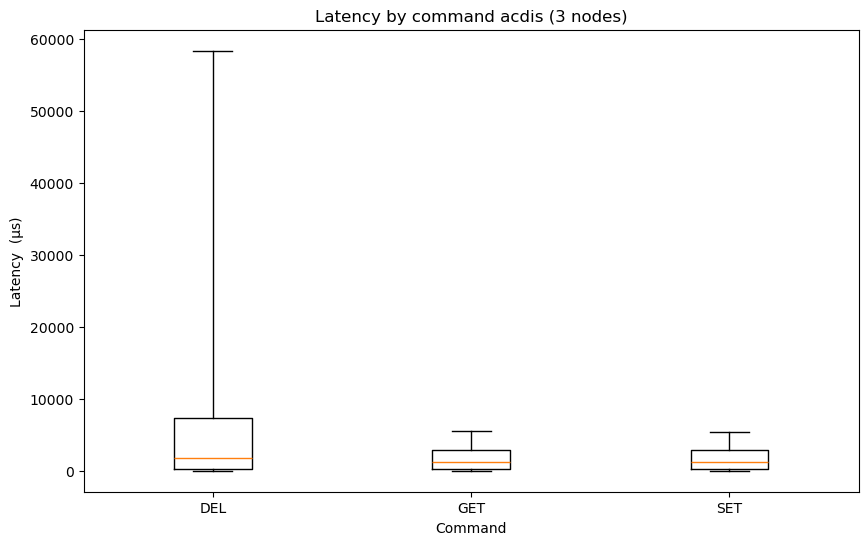

,latency,count
180,257,15192
181,259,13963
182,261,12989
183,263,11802
184,265,11055
185,267,10051
186,269,9074
187,271,8713
188,273,8144
189,275,7518


,latency,count
180,257,7596
181,259,6981
182,261,6494
183,263,5901
184,265,5527
185,267,5025
186,269,4537
187,271,4356
188,273,4072
189,275,3759


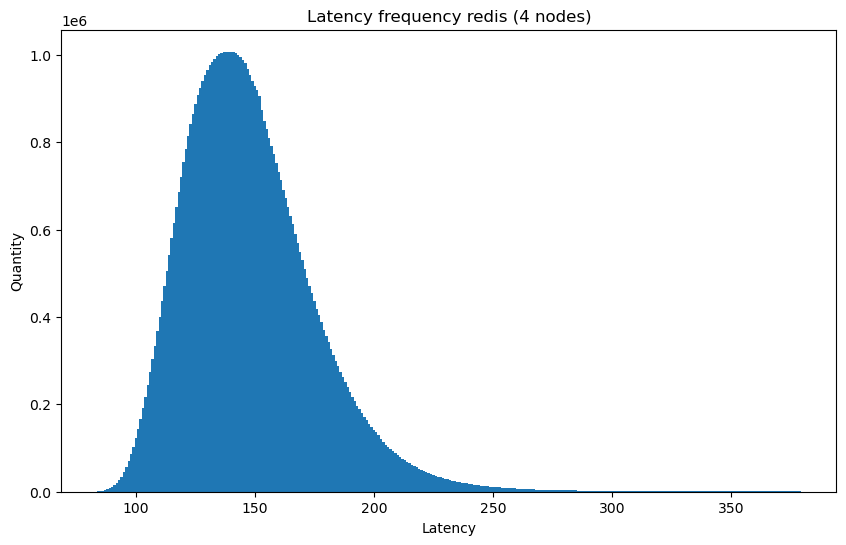

redis DEL: 145  μs
redis GET: 144  μs
redis SET: 150  μs


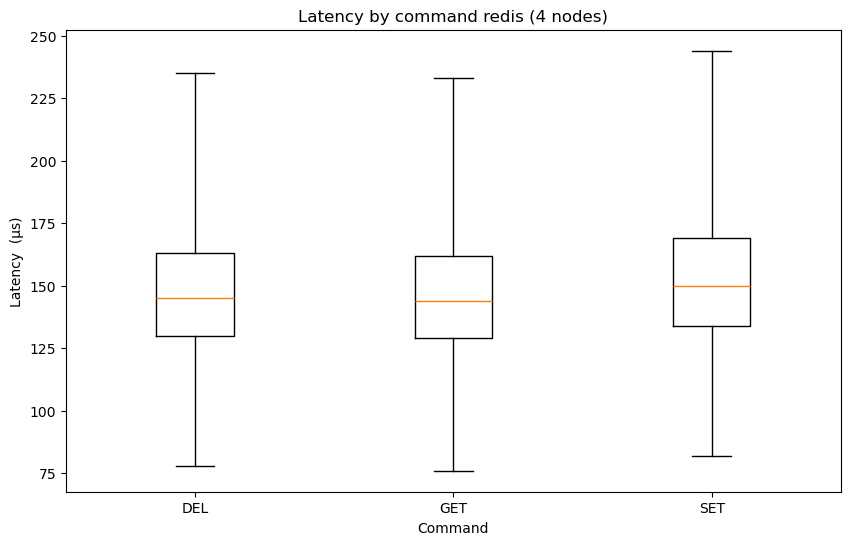

,latency,count
185,257,17366
186,259,16044
187,261,14722
188,263,13591
189,265,12633
...,...,...
249,385,1094
250,387,1145
251,389,1032
252,391,1010


,latency,count
185,257,8683
186,259,8022
187,261,7361
188,263,6795
189,265,6316
...,...,...
249,385,547
250,387,572
251,389,516
252,391,505


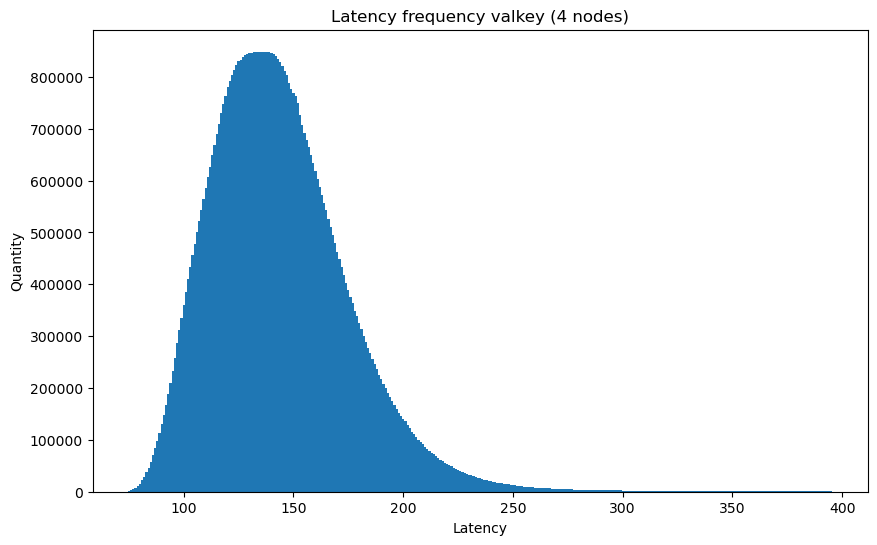

valkey DEL: 141  μs
valkey GET: 140  μs
valkey SET: 145  μs


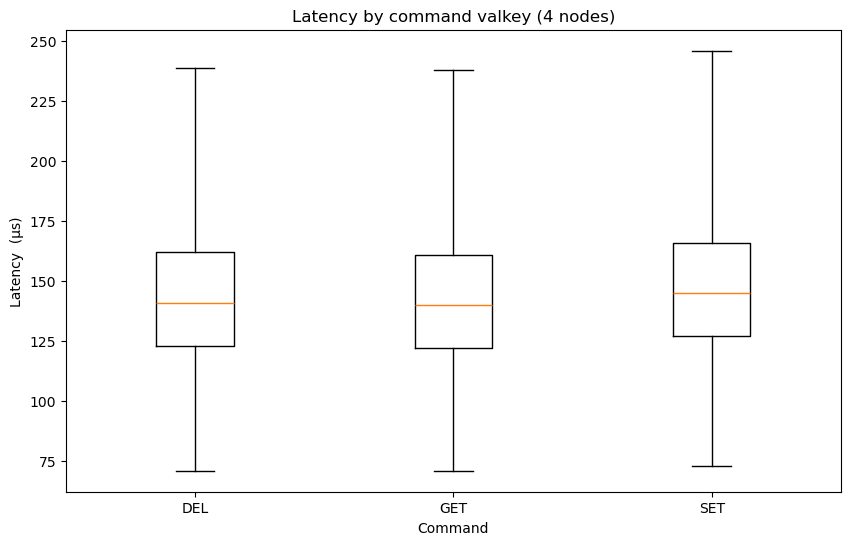

,latency,count
184,257,7497
185,259,7278
186,261,6761
187,263,6595
188,265,6132
189,267,5740
190,269,5677
191,271,5303
192,273,5063
193,275,4702


,latency,count
184,257,3748
185,259,3639
186,261,3380
187,263,3297
188,265,3066
189,267,2870
190,269,2838
191,271,2651
192,273,2531
193,275,2351


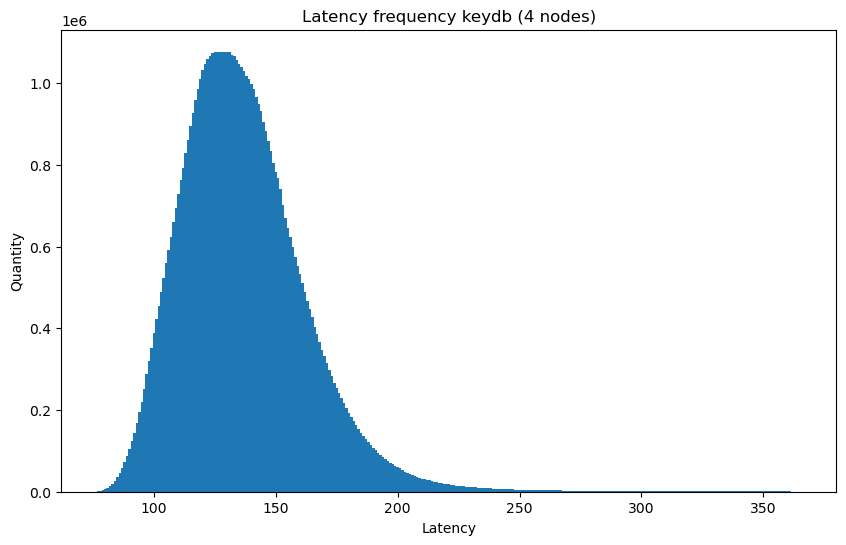

keydb DEL: 134  μs
keydb GET: 133  μs
keydb SET: 140  μs


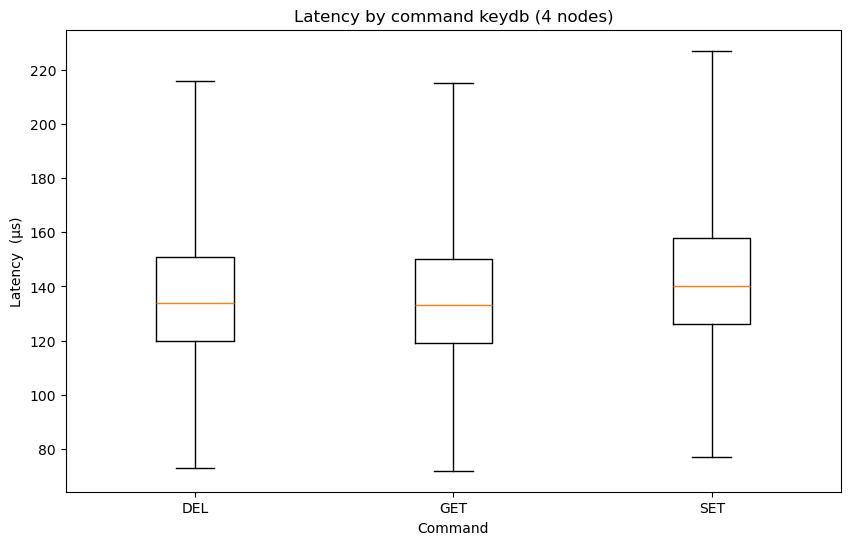

,latency,count
161,257,287
162,259,236
163,261,249
164,263,231
165,265,210
...,...,...
284,503,103
285,505,111
286,507,95
287,509,99


,latency,count
161,257,143
162,259,118
163,261,124
164,263,115
165,265,105
...,...,...
284,503,51
285,505,55
286,507,47
287,509,49


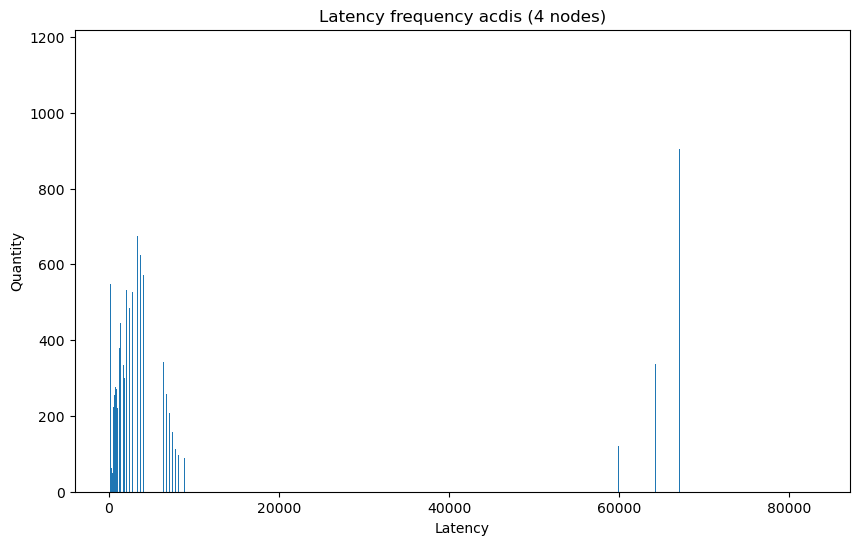

acdis DEL: 5311  μs
acdis GET: 2335  μs
acdis SET: 2351  μs


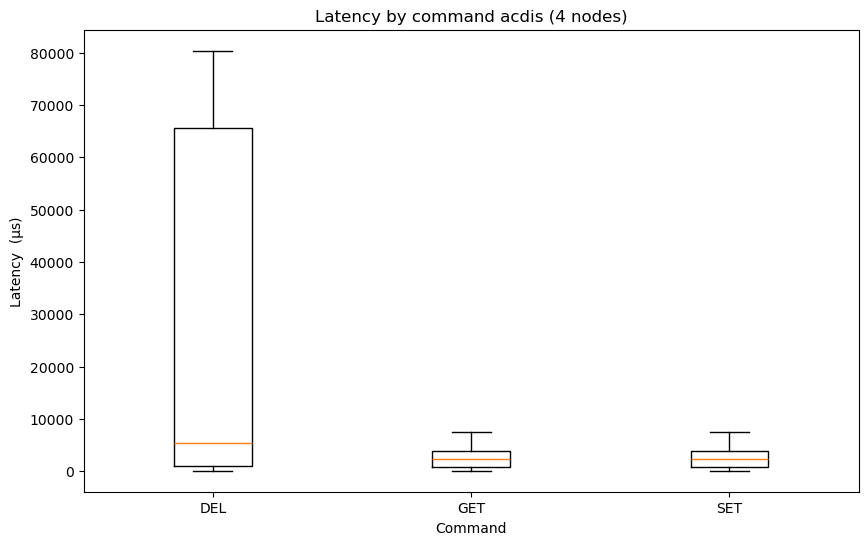

,latency,count
180,257,12660
181,259,11560
182,261,10695
183,263,9931
184,265,9295
185,267,8594
186,269,7880
187,271,7416
188,273,7159
189,275,6424


,latency,count
180,257,6330
181,259,5780
182,261,5347
183,263,4965
184,265,4647
185,267,4297
186,269,3940
187,271,3708
188,273,3579
189,275,3212


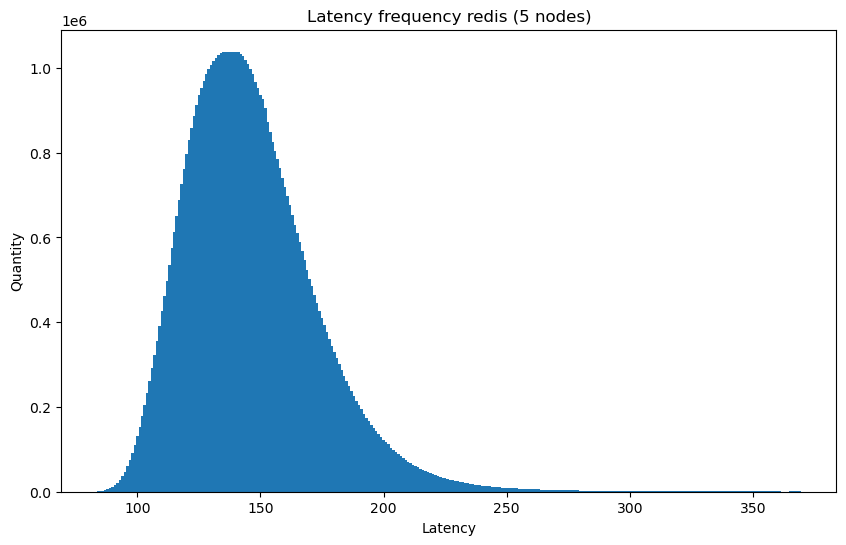

redis DEL: 144  μs
redis GET: 143  μs
redis SET: 148  μs


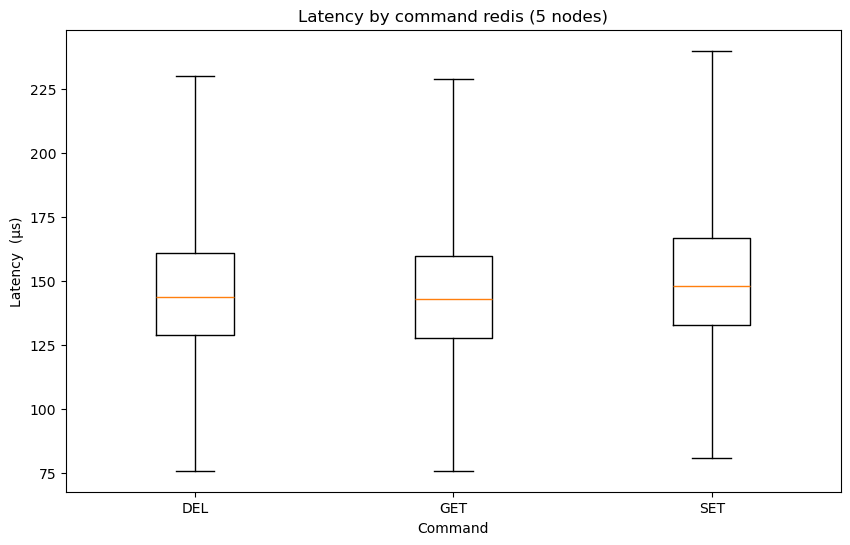

,latency,count
187,257,9248
188,259,8532
189,261,7966
190,263,7566
191,265,7143
192,267,6713
193,269,6289
194,271,5650
195,273,5604
196,275,5168


,latency,count
187,257,4624
188,259,4266
189,261,3983
190,263,3783
191,265,3571
192,267,3356
193,269,3144
194,271,2825
195,273,2802
196,275,2584


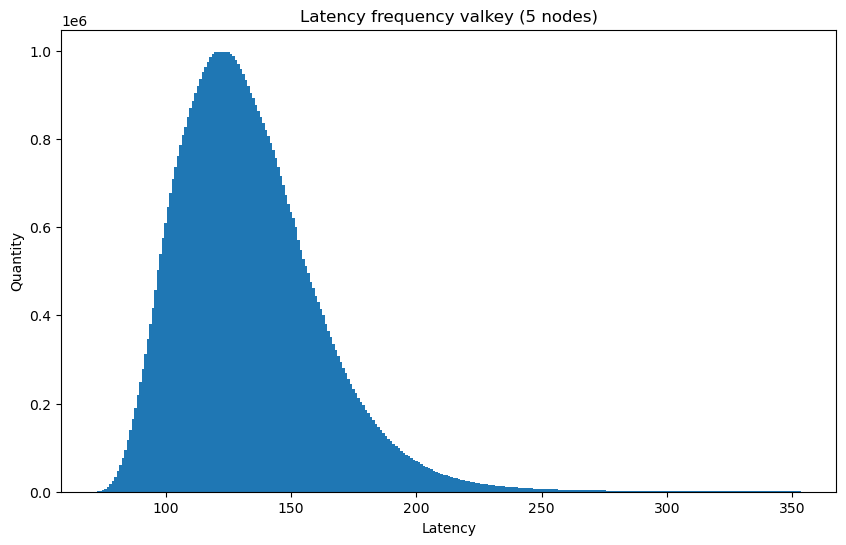

valkey DEL: 130  μs
valkey GET: 129  μs
valkey SET: 135  μs


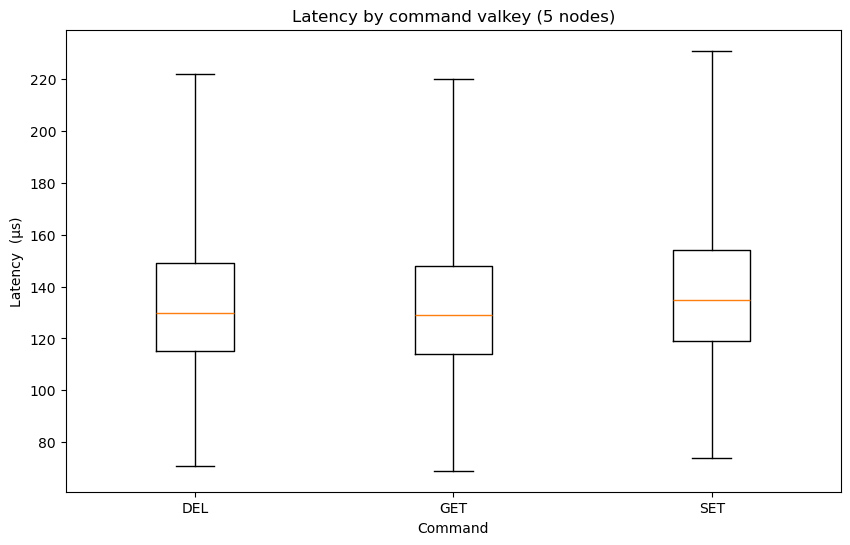

,latency,count
183,257,7072
184,259,6789
185,261,6344
186,263,5999
187,265,5734
188,267,5327
189,269,4992
190,271,5048
191,273,4634
192,275,4449


,latency,count
183,257,3536
184,259,3394
185,261,3172
186,263,2999
187,265,2867
188,267,2663
189,269,2496
190,271,2524
191,273,2317
192,275,2224


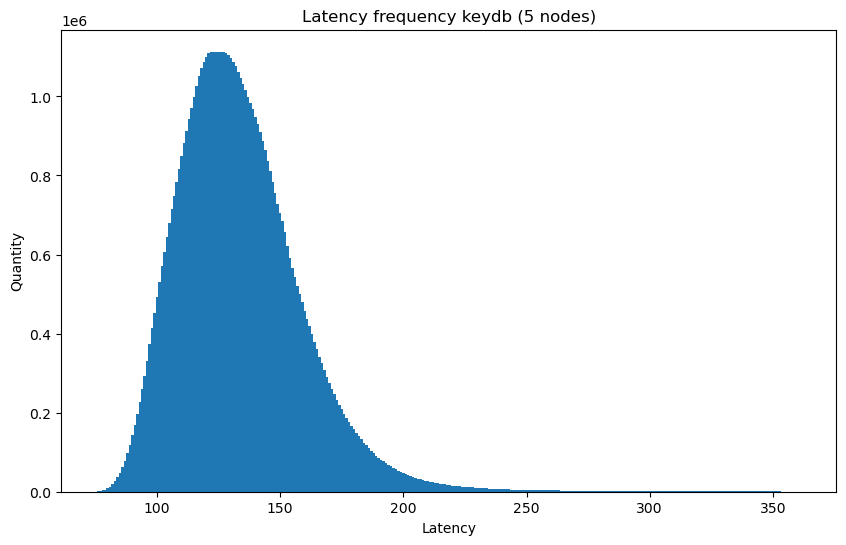

keydb DEL: 131  μs
keydb GET: 130  μs
keydb SET: 137  μs


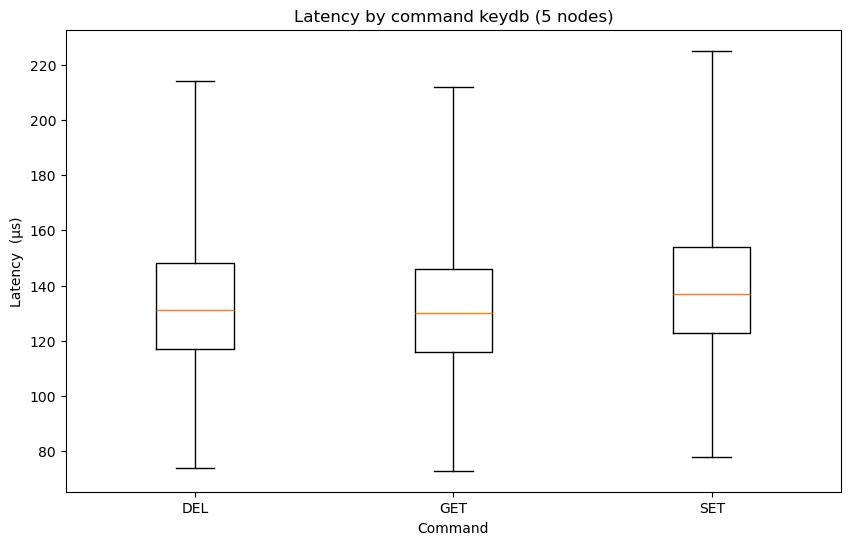

,latency,count
159,257,261
160,259,216
161,261,217
162,263,214
163,265,207
164,267,198
165,269,216
166,271,188
167,273,195
168,275,164


,latency,count
159,257,130
160,259,108
161,261,108
162,263,107
163,265,103
164,267,99
165,269,108
166,271,94
167,273,97
168,275,82


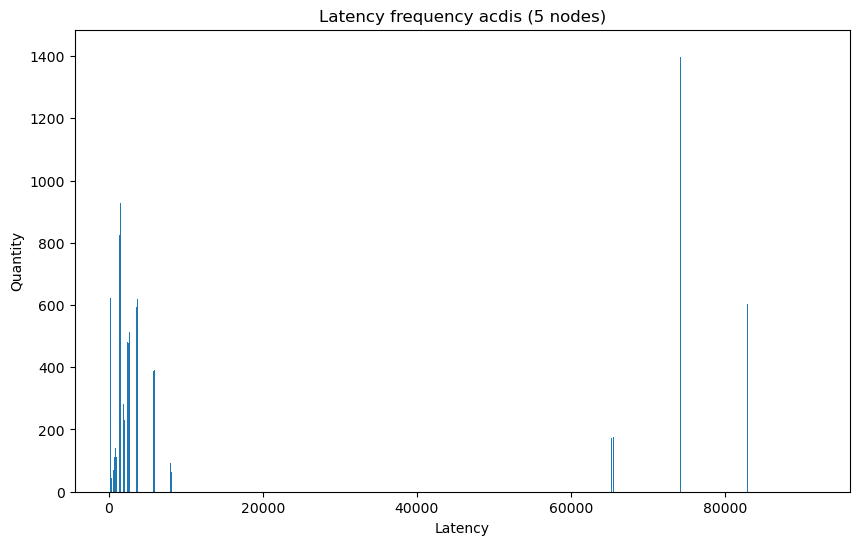

acdis DEL: 66559  μs
acdis GET: 2143  μs
acdis SET: 2175  μs


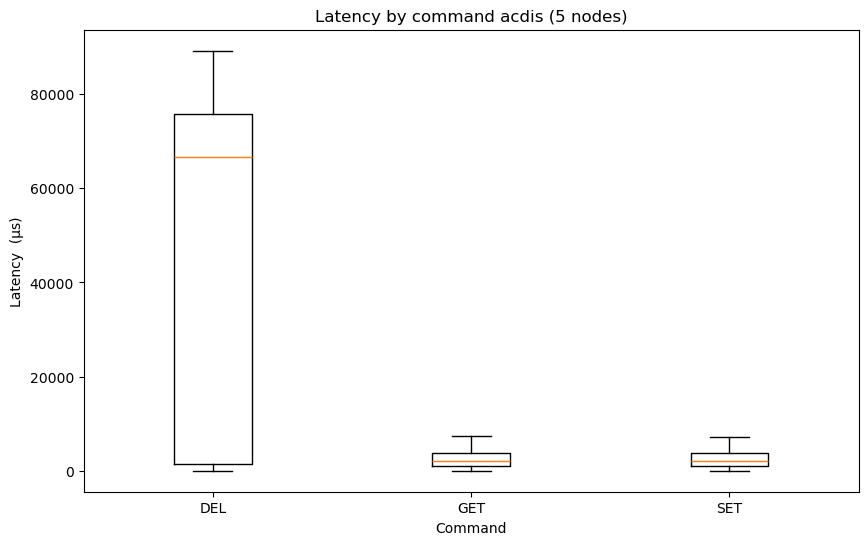

In [39]:
for cluster_size, folders in all_folders.items():
    # Dictionary of percentiles by service
    service_percentiles = {}
    node_percentiles = {}
    for folder in folders:
        service = folder.rstrip("/").split("/")[-1]
        service.rstrip(".csv")
        files = glob.glob(f"{folder}/*.csv")
    
        # List of dataframes for this service
        service_list = []
    
        for file in files:
            df = pd.read_csv(file, comment="#")
            df["service"] = service
            df["node"] = os.path.basename(file).rstrip(".csv")
    
            service_list.append(df)
    
        service_df = pd.concat(service_list, ignore_index=True)

        # Show barcharts for each latency frequency
        fig, ax = plt.subplots(figsize=(10, 6))

        threshold = 50 if service == "acdis" else 1000
        grouped_by_latency = service_df.groupby(["latency"])["count"].sum().reset_index()
        grouped_by_latency = grouped_by_latency[grouped_by_latency["count"] > threshold]

        # hdrhistogram combined values > 255 into buckets. Lets just cut these in half for our graph
        mask = (grouped_by_latency["latency"] > 255) & (grouped_by_latency["latency"] < 512)
        display(grouped_by_latency[mask])
        grouped_by_latency.loc[mask, "count"] = grouped_by_latency[mask] // 2
        display(grouped_by_latency[mask])
        #display(grouped_by_latency["count"][200:265])
        
        plt.bar(grouped_by_latency["latency"], grouped_by_latency["count"], width=5)
        
        ax.set_title(f"Latency frequency {service} ({cluster_size} nodes)")
        ax.set_xlabel("Latency")
        ax.set_ylabel("Quantity")
        plt.savefig(f"images/{cluster_size}-nodes/{service}_latency_frequency.png")
        plt.show()
        plt.close()
    
        ### Analysis per project
        stats_list = []
        
        # Group by command to calculate stats for each box
        commands = service_df.groupby("cmd")
        latencies = []
        for name, cmd in commands:
                # Calculate stats without exploding
                cmd_percentiles = get_weighted_stats(cmd, val_col="latency", weight_col="count", label=name)
                print(f"{service} {cmd_percentiles["label"]}: {cmd_percentiles["med"]}  μs")
                #print(f"Median latency of {cmd} for {name}: {cmd_percentiles["med"]}")
                stats_list.append(cmd_percentiles)
                latencies.append(cmd_percentiles["med"])

        cmd_latencies[service].append(latencies)

        if service != "acdis":
            service_percentiles[service] = get_weighted_stats(service_df, val_col="latency", weight_col="count", label=service)
    
        # Plotting using bxp (Boxplot from pre-calculated stats)
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # bxp takes a list of dictionaries
        ax.bxp(stats_list, showfliers=False) 
        
        ax.set_title(f"Latency by command {service} ({cluster_size} nodes)")
        ax.set_xlabel("Command")
        ax.set_ylabel("Latency  (μs)")
        plt.savefig(f"images/{cluster_size}-nodes/{service}_latency_by_command.png")
        plt.show()
        plt.close()

    cluster_percentiles[cluster_size] = service_percentiles

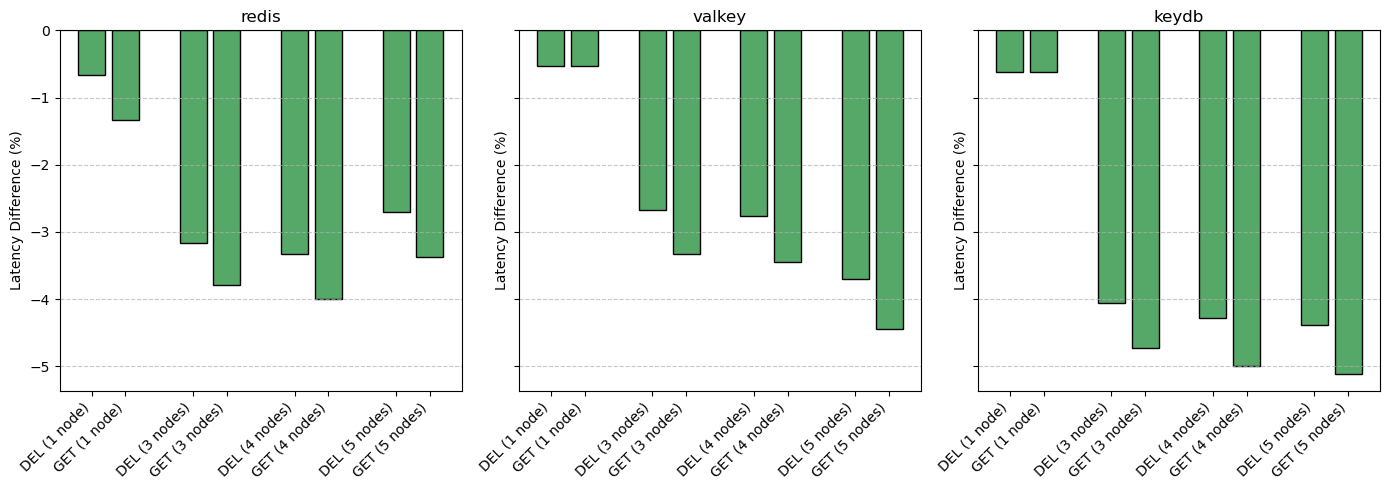

In [18]:
# Generate barcharts to show latency changes of GET, DEL relative to SET
# Turn absolute values to relative ones
relative = { service: [] for service in services }
for service, latencies in cmd_latencies.items():
    for group in latencies:
        # [DEL, GET, SET]
        baseline = group[-1]
        change_del = (group[0]-baseline)/baseline
        change_get = (group[1]-baseline)/baseline
        relative[service].append([change_del, change_get])

def flatten(xss):
    return [x for xs in xss for x in xs]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 5), sharey=True)
counter = 0;

for service, latencies in relative.items():
    if counter == 3:
        break # Skip acdis
    latency_diffs = flatten(latencies)
    latency_diffs = [x * 100 for x in latency_diffs]
    categories = [
        "DEL (1 node)",  "GET (1 node)",
        "DEL (3 nodes)", "GET (3 nodes)",
        "DEL (4 nodes)", "GET (4 nodes)",
        "DEL (5 nodes)", "GET (5 nodes)",
    ]
    
    # 2. Setup Figure
    ax = axes[counter]
    counter += 1

    # 2. Calculate custom X positions
    x_positions = []
    current_x = 0
    gap_size = 1.0  # Adjust this value to make the gap wider or narrower
    
    for i in range(len(categories)):
        x_positions.append(current_x)
        current_x += 1 # Standard width for the next bar
        
        # Add an extra gap after every 2nd bar
        if (i + 1) % 2 == 0:
            current_x += gap_size

    # 3. Dynamic Coloring (Green for negative/faster, Red for positive/slower)
    green = '#55a868'
    red = '#c44e52'
    colors = [red if val >= 0 else green for val in latency_diffs]
    
    # 4. Plot the bars
    bars = ax.bar(x_positions, latency_diffs, color=colors, edgecolor='black', width=0.8)
    
    # 5. Add a distinct zero-line
    ax.axhline(0, color='black', linewidth=1.5)
    # Attach the text labels to the exact coordinates we calculated
    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    
    # 6. Labels and Styling
    ax.set_ylabel('Latency Difference (%)')
    ax.set_title(f"{service}")
    ax.grid(axis='y', linestyle='--', alpha=0.7) # Subtle background grid
    
    # 7. Output
    plt.tight_layout()
    
    # If your window manager doesn't play nicely with matplotlib's default GUI popups, 
    # saving directly to a file is often cleaner:
    plt.savefig('images/cmd_latency_variance.png', dpi=300) 
    
    # Or display it interactively
plt.show()

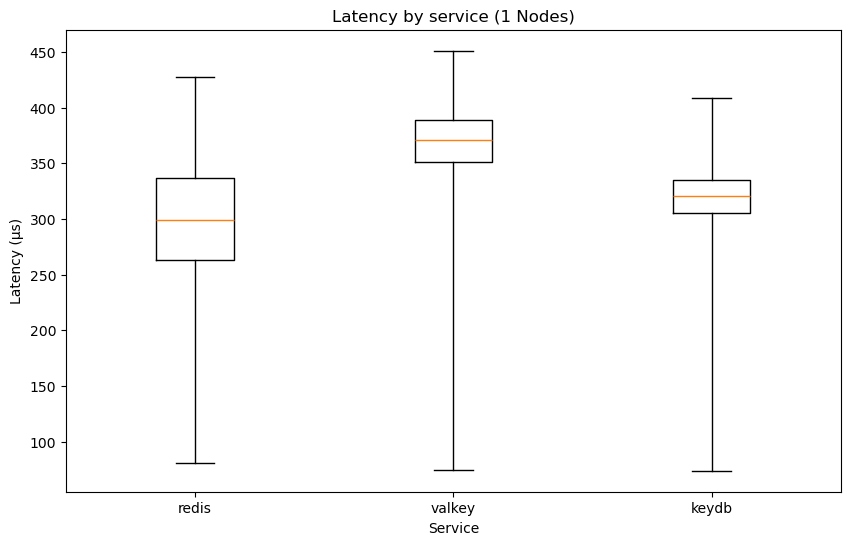

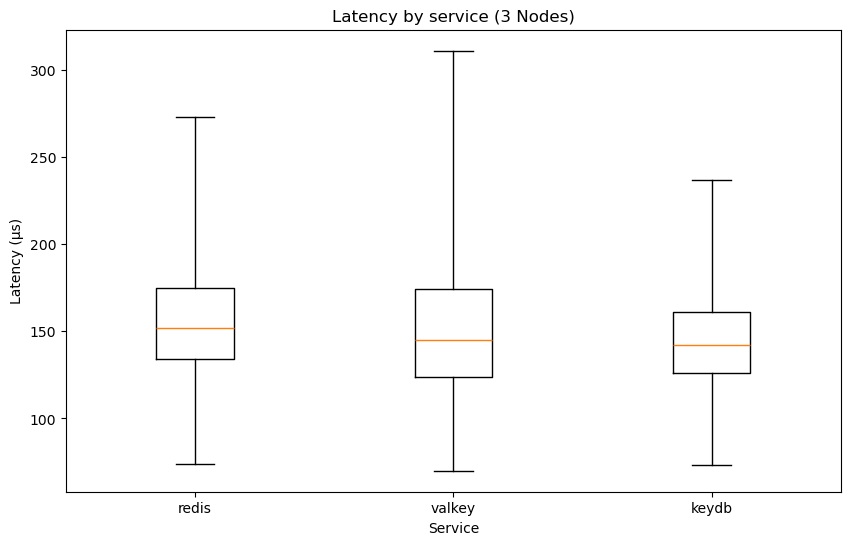

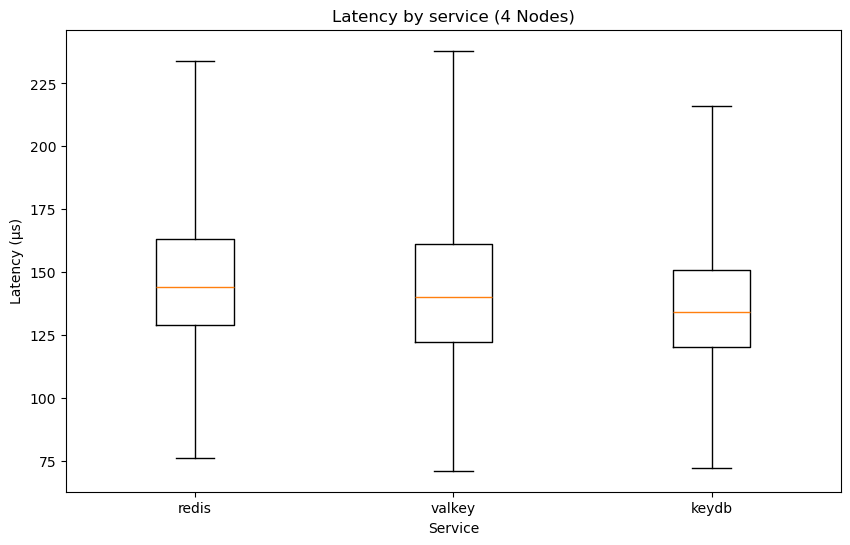

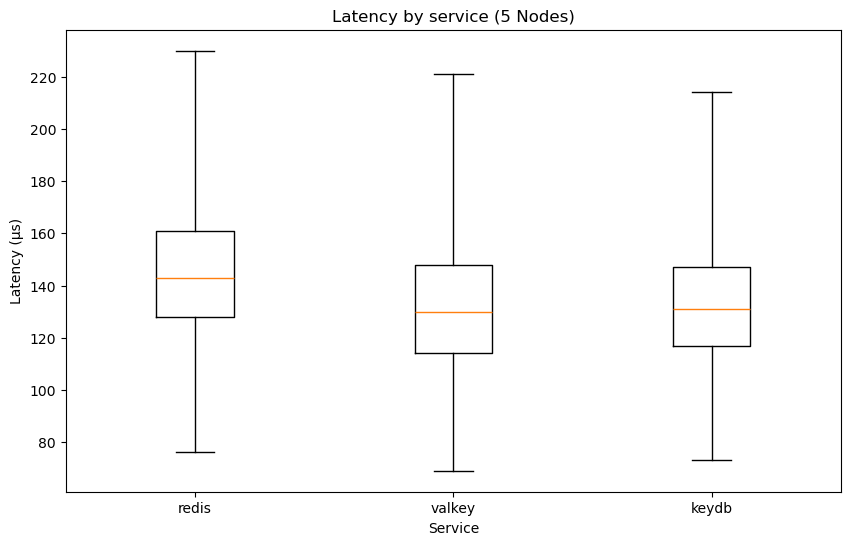

In [19]:
for size, percentiles in cluster_percentiles.items():
    # Plotting using bxp (Boxplot from pre-calculated stats)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # bxp takes a list of dictionaries
    ax.bxp(percentiles.values(), showfliers=False) 
    
    ax.set_title(f"Latency by service ({size} Nodes)")
    ax.set_xlabel("Service")
    ax.set_ylabel("Latency (μs)")
    plt.show()
    plt.close()

In [20]:
# Graph latency for each service with different cluster sizes
same_service_different_size = { service: {} for service in services}
for size, service_dict in cluster_percentiles.items():
    for service, percentiles in service_dict.items():
        percentiles["label"] = size
        same_service_different_size[service][size] = percentiles

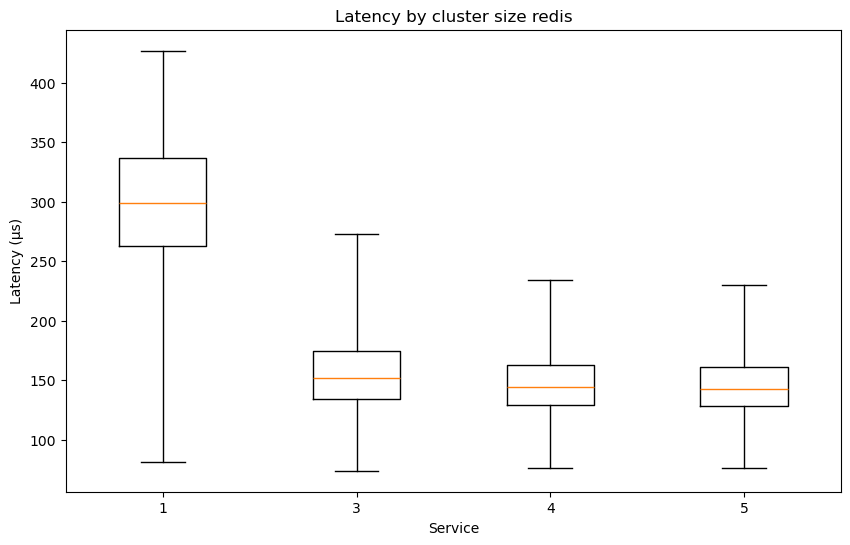

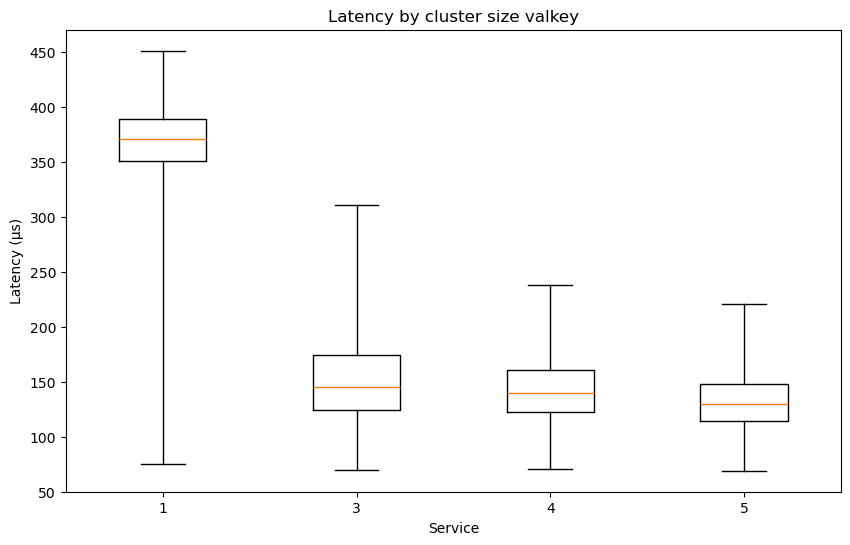

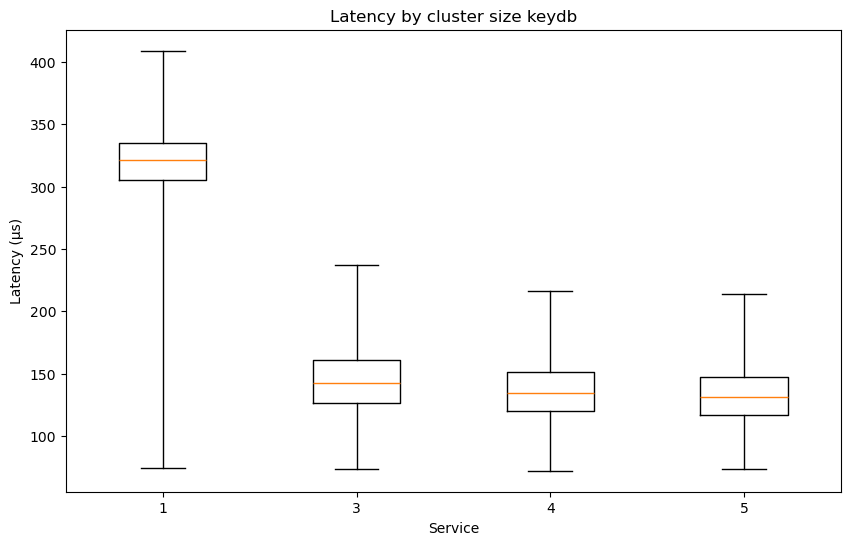

In [21]:
for service, percentiles in same_service_different_size.items():
    if service == "acdis":
        continue
    # Plotting using bxp (Boxplot from pre-calculated stats)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # bxp takes a list of dictionaries
    ax.bxp(percentiles.values(), showfliers=False) 
    
    ax.set_title(f"Latency by cluster size {service}")
    ax.set_xlabel("Service")
    ax.set_ylabel("Latency (μs)")
    plt.savefig(f"images/{service}_latency_by_cluster_size.png")
    plt.show()
    plt.close()

SUT       keydb  redis  valkey
Category                      
One          74     81      75
Three        73     74      70
Four         72     76      71
Five         73     76      69


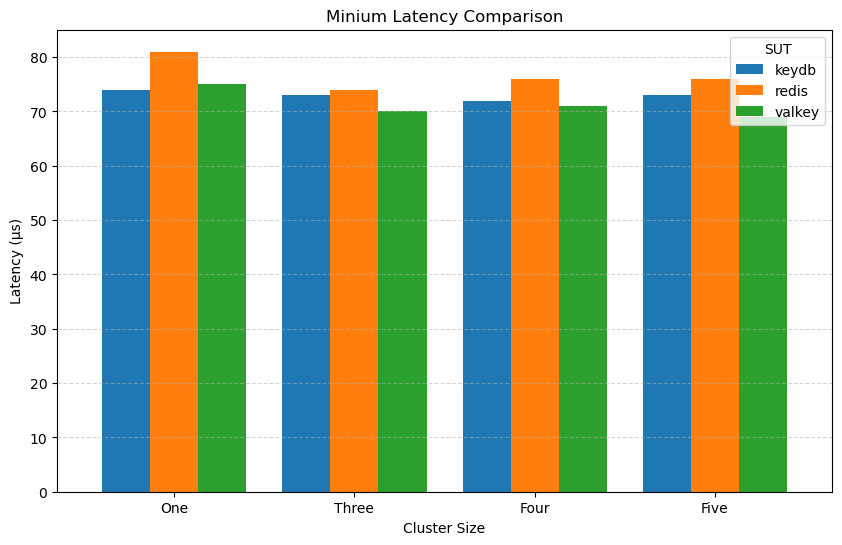

SUT       keydb  redis  valkey
Category                      
One         321    299     371
Three       142    152     145
Four        134    144     140
Five        131    143     130


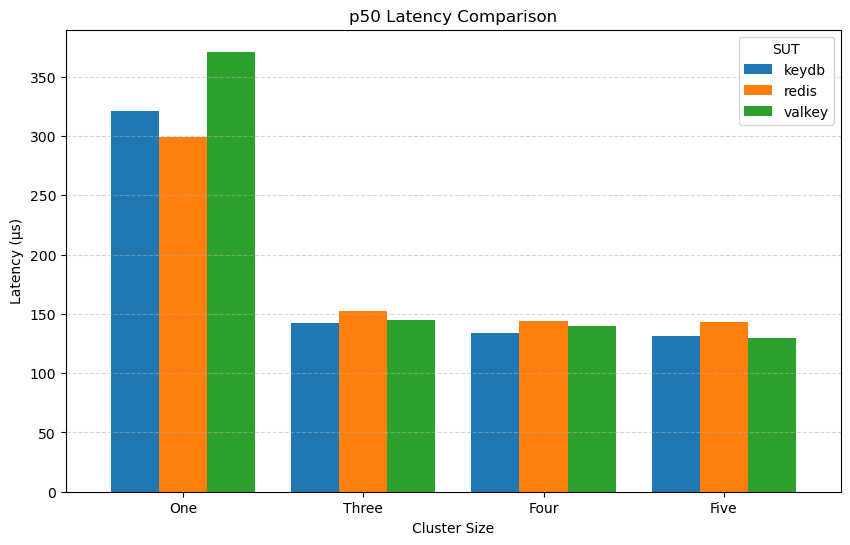

SUT       keydb  redis  valkey
Category                      
One         409    427     451
Three       237    273     311
Four        216    234     238
Five        214    230     221


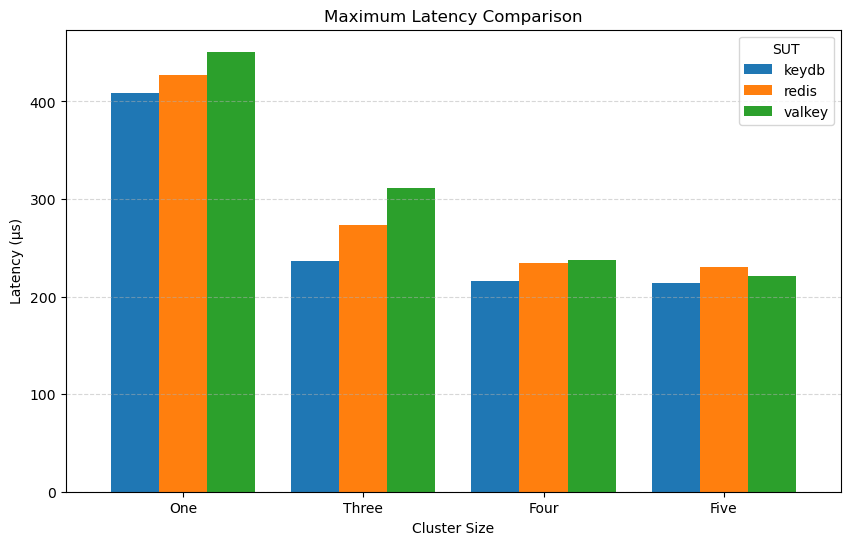

In [10]:
def overview(name, index):
    records = []
    for sut, sizes in same_service_different_size.items():
        if sut != "acdis":
            for size, stats in sizes.items():
                records.append({
                    'SUT': sut, 
                    'Category': size, 
                    name: stats[index]
                })
    
    df = pd.DataFrame(records)
    
    df_pivot = df.pivot(index='Category', columns='SUT', values=name)
    
    # Rename index to words
    df_pivot.index = df_pivot.index.map({1: 'One', 3: 'Three', 4: 'Four', 5: 'Five'})
    print(df_pivot)
    
    ax = df_pivot.plot(kind='bar', figsize=(10, 6), width=0.8)
    
    plt.title(f"{name} Latency Comparison")
    plt.ylabel('Latency (μs)')
    plt.xlabel('Cluster Size')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='SUT')
    plt.savefig(f"images/barchart_{name}_latency.png")
    plt.show()

overview("Minium", "whislo")
overview("p50", "med")
overview("Maximum", "whishi")

In [11]:
def plot_memory(title, path):
    df = pd.read_csv(path, comment="#")
    
    # Drop last entry because it contained 'undefined'
    df = df.head(df.shape[0] -1)
    df = df[5:]
    df = df.drop(columns=['TimeSeries ID'], axis=1)
    # Treat all values as numbers
    df = df.astype(float)
    df = df.rename(columns={
        "tex-chart-0-0": "Node 1",
        "tex-chart-0-1": "Node 2",
        "tex-chart-0-2": "Node 3"
    })
    
    # Extend data so it looks better plotted ###
    last_row = df.iloc[-1]
    last_index = df.index.max()
    new_last = 30
    new_rows = []
    np.random.seed(42)
    for i in range(new_last - last_index):
        jitter = np.random.normal(0, 0.1, size=len(last_row))
        new_row = last_row + jitter
        new_rows.append(new_row)
    
    # Fix index
    start_index = df.index.max() + 1
    new_index = range(start_index, new_last+1)
    df_extended = pd.concat([df, pd.DataFrame(new_rows, index=new_index)])
    
    
    # 1. Find the column and row index of the highest value
    max_col = df_extended.max().idxmax()
    max_row = df_extended[max_col].idxmax()
    max_val = df_extended.loc[max_row, max_col] # Actual value
    print(f"Placing marker at {max_val}!")
    
    
    #### Plot ####
    plt.figure(figsize=(10, 6))
    
    # Plot Lines
    for column in df_extended.columns:
        plt.plot(df_extended.index, df_extended[column], label=column)
    
    # Plot Marker
    plt.scatter(max_row, max_val, color='red', marker='o', s=50, zorder=5)
    plt.annotate(f'OOM Killed', (max_row, max_val), 
                 xytext=(5, 5), textcoords='offset points', color='red')
    
    plt.title(f'Acdis Memory Usage ({title})')
    plt.xlabel('Time')
    plt.xticks([])
    plt.ylabel('Memory Usage (%)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'images/GCP_Memory_{title}.png')

Placing marker at 95.58662862033447!
Placing marker at 94.7026098570705!
Placing marker at 90.75074320839799!


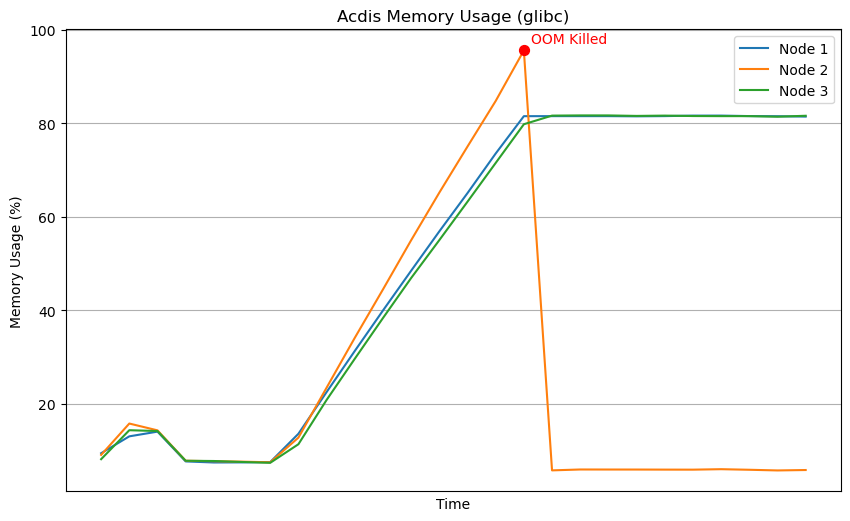

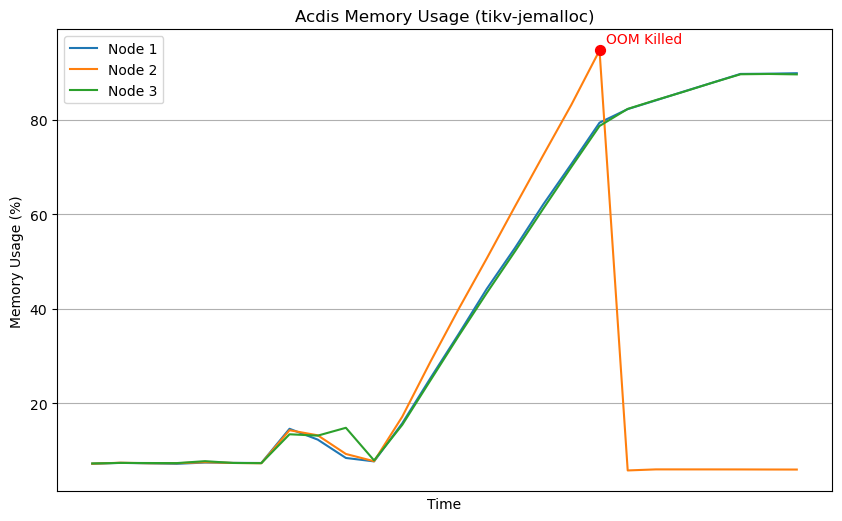

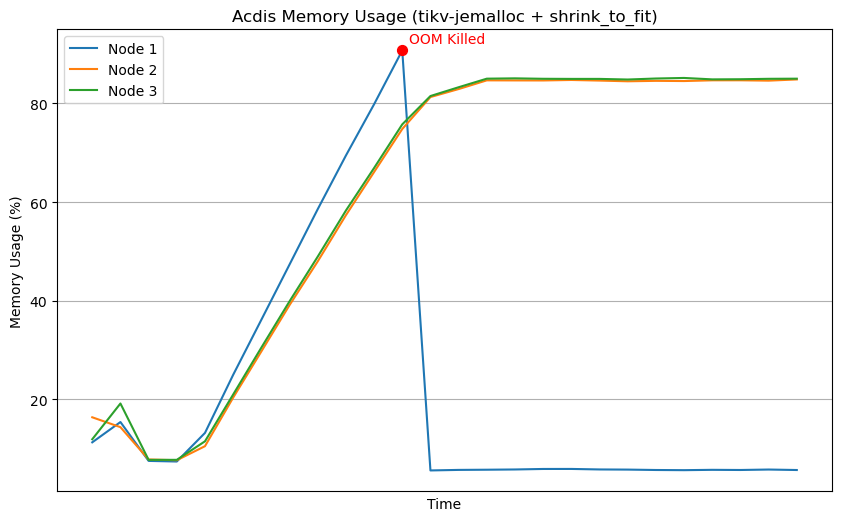

In [12]:
plot_memory("glibc", "gcp_memory/glibc.csv")
plot_memory("tikv-jemalloc", "gcp_memory/tikv-jemalloc.csv")
plot_memory("tikv-jemalloc + shrink_to_fit", "gcp_memory/tikv-jemalloc-shrink.csv")